#Step 1 Complete! Flooded Road Images Extracted

In [ ]:
import os
import cv2
import shutil
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# ============================================================================
# MOUNT DRIVE AND SETUP PATHS
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

# FloodNet paths
FLOODNET_PATH = "/content/drive/MyDrive/Colab Notebooks/FloodNet-Supervised_v1.0"

# Output directory for extracted flooded road images
FLOODED_OUTPUT = "/content/flooded_road_images"
os.makedirs(FLOODED_OUTPUT, exist_ok=True)

# Class value for "Road Flooded" in FloodNet
ROAD_FLOODED_VALUE = 3

print("="*60)
print("EXTRACTING FLOODED ROAD IMAGES FROM FLOODNET")
print("="*60)

# ============================================================================
# EXPLORE FLOODNET STRUCTURE
# ============================================================================

print("\n📂 Exploring FloodNet structure...")

# Define the folder structure
splits = {
    'train': {
        'image_dir': 'train-org-img',
        'label_dir': 'train-label-img'
    },
    'val': {
        'image_dir': 'val-org-img',
        'label_dir': 'val-label-img'
    },
    'test': {
        'image_dir': 'test-org-img',
        'label_dir': 'test-label-img'
    }
}

total_images_copied = 0
split_counts = {}

# ============================================================================
# EXTRACT FLOODED IMAGES FROM EACH SPLIT
# ============================================================================

for split_name, folders in splits.items():
    print(f"\n{'='*40}")
    print(f"Processing: {split_name}")
    print(f"{'='*40}")

    # Build paths
    split_path = os.path.join(FLOODNET_PATH, split_name)
    image_dir = os.path.join(split_path, folders['image_dir'])
    label_dir = os.path.join(split_path, folders['label_dir'])

    # Check if directories exist
    if not os.path.exists(image_dir) or not os.path.exists(label_dir):
        print(f"❌ Directories not found for {split_name}")
        print(f"  Image dir: {image_dir}")
        print(f"  Label dir: {label_dir}")
        continue

    # Get all label files
    label_files = [f for f in os.listdir(label_dir) if f.endswith('.png')]
    print(f"Found {len(label_files)} label files")

    split_count = 0

    # Process each label file
    for label_file in tqdm(label_files, desc=f"Extracting from {split_name}"):
        label_path = os.path.join(label_dir, label_file)

        # Read the label/mask
        mask = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue

        # Check if any pixel is Road Flooded (value = 3)
        if np.any(mask == ROAD_FLOODED_VALUE):
            # Find corresponding image
            # Label file format: e.g., "6463_lab.png" -> image is "6463.jpg"
            base_name = label_file.replace('_lab.png', '.jpg')
            image_path = os.path.join(image_dir, base_name)

            if os.path.exists(image_path):
                # Copy image to output folder with split prefix
                output_filename = f"{split_name}_{base_name}"
                output_path = os.path.join(FLOODED_OUTPUT, output_filename)
                shutil.copy2(image_path, output_path)
                split_count += 1
                total_images_copied += 1

    split_counts[split_name] = split_count
    print(f"✅ Extracted {split_count} flooded road images from {split_name}")

# ============================================================================
# DISPLAY RESULTS
# ============================================================================

print("\n" + "="*60)
print("EXTRACTION COMPLETE!")
print("="*60)
print(f"Total flooded road images extracted: {total_images_copied}")
print(f"Output folder: {FLOODED_OUTPUT}")

print("\nClass distribution:")
for split_name, count in split_counts.items():
    print(f"  {split_name}: {count} images")

# Show sample of extracted files
if total_images_copied > 0:
    print(f"\nSample of extracted files (first 10):")
    sample_files = os.listdir(FLOODED_OUTPUT)[:10]
    for f in sample_files:
        print(f"  - {f}")

# ============================================================================
# ORGANIZE INTO TRAIN/VAL/TEST STRUCTURE
# ============================================================================

print("\n" + "="*60)
print("ORGANIZING INTO TRAIN/VAL/TEST STRUCTURE")
print("="*60)

# Create organized structure
ORGANIZED_FLOODED = "/content/flooded_organized"
for split in ["train", "validation", "test"]:
    os.makedirs(os.path.join(ORGANIZED_FLOODED, split, "flooded"), exist_ok=True)

# Move files based on their prefix
for file in os.listdir(FLOODED_OUTPUT):
    if file.startswith('train_'):
        src = os.path.join(FLOODED_OUTPUT, file)
        dst = os.path.join(ORGANIZED_FLOODED, "train", "flooded", file)
        shutil.copy2(src, dst)
    elif file.startswith('val_'):
        src = os.path.join(FLOODED_OUTPUT, file)
        dst = os.path.join(ORGANIZED_FLOODED, "validation", "flooded", file)
        shutil.copy2(src, dst)
    elif file.startswith('test_'):
        src = os.path.join(FLOODED_OUTPUT, file)
        dst = os.path.join(ORGANIZED_FLOODED, "test", "flooded", file)
        shutil.copy2(src, dst)

print("\n✅ Flooded images organized into:")
print(f"  Train: {len(os.listdir(os.path.join(ORGANIZED_FLOODED, 'train', 'flooded')))} images")
print(f"  Validation: {len(os.listdir(os.path.join(ORGANIZED_FLOODED, 'validation', 'flooded')))} images")
print(f"  Test: {len(os.listdir(os.path.join(ORGANIZED_FLOODED, 'test', 'flooded')))} images")

# ============================================================================
# VERIFY INTEGRITY
# ============================================================================

print("\n" + "="*60)
print("VERIFYING EXTRACTED IMAGES")
print("="*60)

# Check a few images to verify they're valid
import matplotlib.pyplot as plt
from PIL import Image

sample_files = os.listdir(FLOODED_OUTPUT)[:3]
for file in sample_files:
    img_path = os.path.join(FLOODED_OUTPUT, file)
    try:
        img = Image.open(img_path)
        print(f"✅ {file}: {img.size}, {img.mode}")
    except Exception as e:
        print(f"❌ {file}: Error - {e}")

print("\n" + "="*60)
print("FLOODED ROAD EXTRACTION COMPLETE!")
print("="*60)
print(f"✅ {total_images_copied} flooded road images ready for training")
print(f"📁 Organized at: {ORGANIZED_FLOODED}")

Mounted at /content/drive
EXTRACTING FLOODED ROAD IMAGES FROM FLOODNET

📂 Exploring FloodNet structure...

Processing: train
Found 1445 label files


Extracting from train: 100%|██████████| 1445/1445 [03:23<00:00,  7.09it/s]


✅ Extracted 162 flooded road images from train

Processing: val
Found 450 label files


Extracting from val: 100%|██████████| 450/450 [01:02<00:00,  7.14it/s]


✅ Extracted 53 flooded road images from val

Processing: test
Found 448 label files


Extracting from test: 100%|██████████| 448/448 [00:56<00:00,  7.86it/s]


✅ Extracted 49 flooded road images from test

EXTRACTION COMPLETE!
Total flooded road images extracted: 264
Output folder: /content/flooded_road_images

Class distribution:
  train: 162 images
  val: 53 images
  test: 49 images

Sample of extracted files (first 10):
  - test_7476.jpg
  - train_7601.jpg
  - val_7610.jpg
  - train_7542.jpg
  - val_7421.jpg
  - val_7455.jpg
  - train_7520.jpg
  - train_6610.jpg
  - test_7323.jpg
  - val_7329.jpg

ORGANIZING INTO TRAIN/VAL/TEST STRUCTURE

✅ Flooded images organized into:
  Train: 162 images
  Validation: 53 images
  Test: 49 images

VERIFYING EXTRACTED IMAGES
✅ test_7476.jpg: (4592, 3072), RGB
✅ train_7601.jpg: (4592, 3072), RGB
✅ val_7610.jpg: (4592, 3072), RGB

FLOODED ROAD EXTRACTION COMPLETE!
✅ 264 flooded road images ready for training
📁 Organized at: /content/flooded_organized


#Step 2: Extract and Explore Road Traversing Dataset

In [ ]:
import os
import zipfile
from tqdm import tqdm

# ============================================================================
# MOUNT DRIVE
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

# ============================================================================
# FIND THE ZIP FILE
# ============================================================================

print("="*60)
print("FINDING ROAD QUALITY CLASSIFICATION ZIP FILE")
print("="*60)

# Search for the zip file
zip_path = None
search_paths = [
    "/content/drive/MyDrive/RoadQualityClassification.zip",
    "/content/drive/MyDrive/RoadQualityClassification/RoadQualityClassification.zip",
    "/content/drive/MyDrive/Colab Notebooks/RoadQualityClassification.zip",
    "/content/drive/MyDrive/Downloads/RoadQualityClassification.zip",
]

for path in search_paths:
    if os.path.exists(path):
        zip_path = path
        print(f"✅ Found zip file at: {zip_path}")
        break

# If not found, search for it
if zip_path is None:
    print("\n🔍 Searching for RoadQualityClassification.zip in Drive...")
    for root, dirs, files in os.walk("/content/drive/MyDrive", topdown=True): # Removed maxdepth
        for file in files:
            if "RoadQuality" in file and file.endswith('.zip'):
                zip_path = os.path.join(root, file)
                print(f"✅ Found zip file at: {zip_path}")
                break
        if zip_path:
            break

if zip_path is None:
    print("\n❌ Could not find RoadQualityClassification.zip")
    print("Please upload it to your Drive and try again.")
    print("\nOr check the path and update the search paths above.")

# ============================================================================
# EXTRACT THE ZIP FILE
# ============================================================================

if zip_path:
    print("\n" + "="*60)
    print("EXTRACTING ZIP FILE")
    print("="*60)

    # Output directory for extraction
    extract_dir = "/content/RoadQualityClassification"
    os.makedirs(extract_dir, exist_ok=True)

    print(f"Extracting to: {extract_dir}")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # Get total files for progress bar
        total_files = len(zip_ref.namelist())
        print(f"Total files in zip: {total_files}")

        # Extract with progress bar
        extracted_count = 0
        with tqdm(total=total_files, desc="Extracting") as pbar:
            for file in zip_ref.namelist():
                zip_ref.extract(file, extract_dir)
                extracted_count += 1
                pbar.update(1)

    print(f"\n✅ Extraction complete! Extracted {extracted_count} files")

    # Check for a nested zip file and extract it if found
    # The expected dataset path is DATASET_PATH = "/content/RoadQualityClassification/Road Traversing Knowledge for Quality Classification"
    # This implies that "Road Traversing Knowledge for Quality Classification/" is a subfolder.
    # The `extract_dir` is `/content/RoadQualityClassification`.

    road_traversing_root = os.path.join(extract_dir, "Road Traversing Knowledge for Quality Classification")

    if os.path.exists(road_traversing_root) and os.path.isdir(road_traversing_root):
        print(f"\n🔍 Found potential Road Traversing root: {road_traversing_root}")
        inner_zip_path = None
        # Search for a zip file within this root, assuming it's directly inside
        for file in os.listdir(road_traversing_root):
            if "RoadQuality" in file and file.endswith('.zip'):
                inner_zip_path = os.path.join(road_traversing_root, file)
                break

        if inner_zip_path and inner_zip_path != zip_path: # Ensure we don't try to extract the same zip again
            print(f"📦 Found nested zip file: {inner_zip_path}")
            print(f"   Extracting nested zip to: {road_traversing_root}")

            try:
                with zipfile.ZipFile(inner_zip_path, 'r') as inner_zip_ref:
                    total_inner_files = len(inner_zip_ref.namelist())
                    print(f"   Total files in nested zip: {total_inner_files}")
                    inner_extracted_count = 0
                    with tqdm(total=total_inner_files, desc=f"Extracting nested {os.path.basename(inner_zip_path)}") as inner_pbar:
                        for inner_file in inner_zip_ref.namelist():
                            inner_zip_ref.extract(inner_file, road_traversing_root) # Extract to the same road_traversing_root
                            inner_extracted_count += 1
                            inner_pbar.update(1)
                print(f"✅ Nested extraction complete! Extracted {inner_extracted_count} files.")
                # Remove the nested zip after extraction to avoid confusion
                os.remove(inner_zip_path)
                print(f"🗑️ Removed nested zip: {inner_zip_path}")
            except zipfile.BadZipFile:
                print(f"❌ Error: The nested file {inner_zip_path} is not a valid zip file.")
            except Exception as e:
                print(f"❌ An unexpected error occurred during nested extraction: {e}")
        else:
            print("❌ No nested zip file found for further extraction within Road Traversing root or it was the same as the outer zip.")
    else:
        print(f"❌ Road Traversing root directory not found at: {road_traversing_root}")

# ============================================================================
# EXPLORE THE EXTRACTED STRUCTURE
# ============================================================================

print("\n" + "="*60)
print("EXPLORING EXTRACTED STRUCTURE")
print("="*60)

# Check what was extracted
extracted_path = extract_dir

# Now, with the primary extracted_path, proceed to list contents and find images
if os.path.exists(extracted_path):
    print(f"\n📁 Contents of {extracted_path}:")
    contents = os.listdir(extracted_path)
    for item in contents:
        item_path = os.path.join(extracted_path, item)
        if os.path.isdir(item_path):
            print(f"   📁 {item}/")
        else:
            size = os.path.getsize(item_path) / (1024 * 1024)
            print(f"   📄 {item} ({size:.2f} MB)")

    # Check if there's a subfolder with the dataset
    print("\n🔍 Looking for image folders...")

    # Look for folders containing image data
    image_folders = []
    for root, dirs, files in os.walk(extracted_path, topdown=True): # Removed maxdepth
        # Check if this folder contains images
        image_files = [f for f in files if f.endswith(('.jpg', '.jpeg', '.png'))]
        if len(image_files) > 0:
            rel_path = os.path.relpath(root, extracted_path)
            if rel_path != '.':
                image_folders.append({
                    'path': root,
                    'rel_path': rel_path,
                    'image_count': len(image_files),
                    'sample_files': image_files[:5]
                })

    if image_folders:
        print(f"\nFound {len(image_folders)} folders containing images:")
        for folder in image_folders:
            print(f"\n📁 {folder['rel_path']}/")
            print(f"   Images: {folder['image_count']}")
            print(f"   Samples: {folder['sample_files'][:3]}")
    else:
        print("\n⚠ No image folders found directly.")
        print("Showing all contents:")
        for root, dirs, files in os.walk(extracted_path, topdown=True): # Removed maxdepth
            level = root.replace(extracted_path, '').count(os.sep)
            indent = ' ' * 2 * level
            print(f"{indent}{os.path.basename(root)}/")
            subindent = ' ' * 2 * (level + 1)
            for d in dirs[:5]:
                print(f"{subindent}📁 {d}/")
            for f in files[:5]:
                size = os.path.getsize(os.path.join(root, f)) / (1024 * 1024)
                print(f"{subindent}📄 {f} ({size:.2f} MB)")
            if len(files) > 5:
                print(f"{subindent}... and {len(files)-5} more files")
else:
    print("\n❌ Could not find extracted folder")
    print(f"   Looking for: {extracted_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FINDING ROAD QUALITY CLASSIFICATION ZIP FILE
✅ Found zip file at: /content/drive/MyDrive/Colab Notebooks/RoadQualityClassification.zip

EXTRACTING ZIP FILE
Extracting to: /content/RoadQualityClassification
Total files in zip: 1


Extracting: 100%|██████████| 1/1 [00:05<00:00,  5.14s/it]



✅ Extraction complete! Extracted 1 files

🔍 Found potential Road Traversing root: /content/RoadQualityClassification/Road Traversing Knowledge for Quality Classification
📦 Found nested zip file: /content/RoadQualityClassification/Road Traversing Knowledge for Quality Classification/RoadQualityClassification.zip
   Extracting nested zip to: /content/RoadQualityClassification/Road Traversing Knowledge for Quality Classification
   Total files in nested zip: 6306


Extracting nested RoadQualityClassification.zip: 100%|██████████| 6306/6306 [00:03<00:00, 1583.21it/s]

✅ Nested extraction complete! Extracted 6306 files.
🗑️ Removed nested zip: /content/RoadQualityClassification/Road Traversing Knowledge for Quality Classification/RoadQualityClassification.zip

EXPLORING EXTRACTED STRUCTURE

📁 Contents of /content/RoadQualityClassification:
   📁 Road Traversing Knowledge for Quality Classification/

🔍 Looking for image folders...

Found 8 folders containing images:

📁 Road Traversing Knowledge for Quality Classification/RoadQualityClassification/asphalt_good/
   Images: 1978
   Samples: ['000001127.jpg', '000001717.jpg', '000000586.jpg']

📁 Road Traversing Knowledge for Quality Classification/RoadQualityClassification/asphalt_bad/
   Images: 464
   Samples: ['000000222.jpg', '000000404.jpg', '000000372.jpg']

📁 Road Traversing Knowledge for Quality Classification/RoadQualityClassification/unpaved_bad/
   Images: 593
   Samples: ['000000586.jpg', '000000222.jpg', '000000404.jpg']

📁 Road Traversing Knowledge for Quality Classification/RoadQualityClassif

#Step 2: Organize Road Traversing Dataset (Good & Rough Roads)

In [ ]:
import os
import shutil
import random
from tqdm import tqdm

# ============================================================================
# SETUP PATHS
# ============================================================================

# The dataset path from exploration
DATASET_PATH = "/content/RoadQualityClassification/Road Traversing Knowledge for Quality Classification/RoadQualityClassification"

# Output paths
OUTPUT_DIR = os.path.join("/content", "road_traversing_organized")
TRAIN_DIR = os.path.join(OUTPUT_DIR, "train")
VAL_DIR = os.path.join(OUTPUT_DIR, "validation")
TEST_DIR = os.path.join(OUTPUT_DIR, "test")

print("="*60)
print("ORGANIZING ROAD TRAVERSING DATASET")
print("="*60)

# Create output directories
print("\n📁 Creating output directories...")
for dir_path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for class_name in ["good", "rough"]:
        os.makedirs(os.path.join(dir_path, class_name), exist_ok=True)

# ============================================================================
# CLASS MAPPING
# ============================================================================

class_mapping = {
    "asphalt_good": "good",
    "paved_good": "good",
    "asphalt_regular": "rough",
    "asphalt_bad": "rough",
    "paved_regular": "rough",
    "paved_bad": "rough",
    "unpaved_regular": "rough",
    "unpaved_bad": "rough"
}

print("\nClass Mapping:")
for folder, class_name in class_mapping.items():
    print(f"  {folder} → {class_name}")

# ============================================================================
# COPY IMAGES TO TRAIN FOLDER FIRST
# ============================================================================

print("\n📂 Copying images from source folders...")

copied_counts = {"good": 0, "rough": 0}

# Get all folders in the dataset
folders = [f for f in os.listdir(DATASET_PATH)
           if os.path.isdir(os.path.join(DATASET_PATH, f))]

print(f"\nFound {len(folders)} folders")

for folder_name in folders:
    folder_path = os.path.join(DATASET_PATH, folder_name)

    # Determine target class
    if folder_name in class_mapping:
        target_class = class_mapping[folder_name]
    else:
        print(f"⚠ Skipping unknown folder: {folder_name}")
        continue

    # Get all images
    images = [f for f in os.listdir(folder_path)
              if f.endswith(('.jpg', '.jpeg', '.png'))]

    print(f"\n📁 {folder_name} → {target_class}")
    print(f"   {len(images)} images")

    # Copy each image
    for img in tqdm(images, desc=f"Copying {target_class}"):
        src_path = os.path.join(folder_path, img)

        # Create unique name with source folder prefix
        new_name = f"{folder_name}_{img}"
        dst_path = os.path.join(TRAIN_DIR, target_class, new_name)

        try:
            shutil.copy2(src_path, dst_path)
            copied_counts[target_class] += 1
        except Exception as e:
            print(f"   ⚠ Error copying {img}: {e}")

print("\n" + "="*60)
print("COPYING COMPLETE!")
print("="*60)
print(f"✅ Good Road images: {copied_counts['good']}")
print(f"✅ Rough Road images: {copied_counts['rough']}")
print(f"✅ Total: {copied_counts['good'] + copied_counts['rough']}")

# ============================================================================
# SPLIT INTO TRAIN/VALIDATION/TEST (70/15/15)
# ============================================================================

print("\n" + "="*60)
print("SPLITTING DATA INTO TRAIN/VALIDATION/TEST (70/15/15)")
print("="*60)

class_names = ["good", "rough"]

for class_name in class_names:
    src_dir = os.path.join(TRAIN_DIR, class_name)

    if not os.path.exists(src_dir):
        print(f"❌ Class directory not found: {class_name}")
        continue

    files = [f for f in os.listdir(src_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

    if len(files) == 0:
        print(f"⚠ No images found for class: {class_name}")
        continue

    # Shuffle
    random.shuffle(files)

    total = len(files)
    train_count = int(0.7 * total)
    val_count = int(0.15 * total)

    train_files = files[:train_count]
    val_files = files[train_count:train_count + val_count]
    test_files = files[train_count + val_count:]

    print(f"\n{class_name.upper()}:")
    print(f"  Total: {total} images")
    print(f"  Train: {len(train_files)} (70%)")
    print(f"  Validation: {len(val_files)} (15%)")
    print(f"  Test: {len(test_files)} (15%)")

    # Copy to validation
    for file in val_files:
        src = os.path.join(src_dir, file)
        dst = os.path.join(VAL_DIR, class_name, file)
        shutil.copy2(src, dst)

    # Copy to test
    for file in test_files:
        src = os.path.join(src_dir, file)
        dst = os.path.join(TEST_DIR, class_name, file)
        shutil.copy2(src, dst)

# ============================================================================
# VERIFY FINAL STRUCTURE
# ============================================================================

print("\n" + "="*60)
print("FINAL DATASET VERIFICATION")
print("="*60)

for split in ["train", "validation", "test"]:
    split_path = os.path.join(OUTPUT_DIR, split)
    print(f"\n{split.upper()}:")

    for class_name in ["good", "rough"]:
        class_path = os.path.join(split_path, class_name)
        if os.path.exists(class_path):
            count = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
            print(f"  {class_name}: {count} images")
        else:
            print(f"  {class_name}: 0 images")

print("\n" + "="*60)
print("ROAD TRAVERSING DATASET ORGANIZATION COMPLETE!")
print("="*60)
print(f"📁 Output folder: {OUTPUT_DIR}")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*60)
print("CURRENT DATASET STATUS")
print("="*60)

print("\n✅ Step 1 - Flooded Roads:")
print(f"   Train: 162 images")
print(f"   Validation: 53 images")
print(f"   Test: 49 images")
print(f"   Total: 264 images")

print("\n✅ Step 2 - Road Traversing (Good & Rough):")
good_total = len(os.listdir(os.path.join(OUTPUT_DIR, "train", "good"))) + \
             len(os.listdir(os.path.join(OUTPUT_DIR, "validation", "good"))) + \
             len(os.listdir(os.path.join(OUTPUT_DIR, "test", "good")))
rough_total = len(os.listdir(os.path.join(OUTPUT_DIR, "train", "rough"))) + \
              len(os.listdir(os.path.join(OUTPUT_DIR, "validation", "rough"))) + \
              len(os.listdir(os.path.join(OUTPUT_DIR, "test", "rough")))
print(f"   Good Road: {good_total} images")
print(f"   Rough Road: {rough_total} images")
print(f"   Total: {good_total + rough_total} images")

print("\n⏳ Remaining:")
print("   - Crack (need Unified Dataset)")
print("   - Pothole (need Unified Dataset)")

ORGANIZING ROAD TRAVERSING DATASET

📁 Creating output directories...

Class Mapping:
  asphalt_good → good
  paved_good → good
  asphalt_regular → rough
  asphalt_bad → rough
  paved_regular → rough
  paved_bad → rough
  unpaved_regular → rough
  unpaved_bad → rough

📂 Copying images from source folders...

Found 8 folders

📁 asphalt_good → good
   1978 images


Copying good: 100%|██████████| 1978/1978 [00:00<00:00, 7610.44it/s]



📁 asphalt_bad → rough
   464 images


Copying rough: 100%|██████████| 464/464 [00:00<00:00, 8096.88it/s]



📁 unpaved_bad → rough
   593 images


...


📁 paved_bad → rough
   124 images


Copying rough: 100%|██████████| 124/124 [00:00<00:00, 4876.87it/s]



📁 asphalt_regular → rough
   839 images


Copying rough: 100%|██████████| 839/839 [00:00<00:00, 5770.00it/s]



COPYING COMPLETE!
✅ Good Road images: 3157
✅ Rough Road images: 3140
✅ Total: 6297

SPLITTING DATA INTO TRAIN/VALIDATION/TEST (70/15/15)

GOOD:
  Total: 3157 images
  Train: 2209 (70%)
  Validation: 473 (15%)
  Test: 475 (15%)

ROUGH:
  Total: 3140 images
  Train: 2198 (70%)
  Validation: 471 (15%)
  Test: 471 (15%)

FINAL DATASET VERIFICATION

TRAIN:
  good: 3157 images
  rough: 3140 images

VALIDATION:
  good: 473 images
  rough: 471 images

TEST:
  good: 475 images
  rough: 471 images

ROAD TRAVERSING DATASET ORGANIZATION COMPLETE!
📁 Output folder: /content/road_traversing_organized

CURRENT DATASET STATUS

✅ Step 1 - Flooded Roads:
   Train: 162 images
   Validation: 53 images
   Test: 49 images
   Total: 264 images

✅ Step 2 - Road Traversing (Good & Rough):
   Good Road: 4105 images
   Rough Road: 4082 images
   Total: 8187 images

⏳ Remaining:
   - Crack (need Unified Dataset)
   - Pothole (need Unified Dataset)


#Step 3: Download and Extract Unified Dataset

In [ ]:
import os
import tarfile
import shutil
import random
from tqdm import tqdm
from huggingface_hub import hf_hub_download, login

# ============================================================================
# LOGIN TO HUGGING FACE
# ============================================================================

print("="*60)
print("HUGGING FACE LOGIN")
print("="*60)

# You need a Hugging Face account (free) - sign up at huggingface.co/join
# Run login() and enter your token when prompted

try:
    login()
    print("✅ Logged in successfully!")
except Exception as e:
    print(f"❌ Login error: {e}")
    print("\nIf you don't have a Hugging Face account:")
    print("1. Go to huggingface.co/join")
    print("2. Sign up (takes 2 minutes)")
    print("3. Create an access token: huggingface.co/settings/tokens")
    print("4. Run login() and paste the token")

# ============================================================================
# DOWNLOAD UNIFIED DATASET
# ============================================================================

print("\n" + "="*60)
print("DOWNLOADING UNIFIED ROAD DEFECT DATASET")
print("="*60)

dataset_repo_id = "TamAko783/Unified_Road_Defect_Dataset"
filenames = ["data/train_a.tar.gz", "data/train_b.tar.gz", "data/val.tar.gz"]

downloaded_files = []

for filename in filenames:
    print(f"\n📥 Downloading: {filename}")
    try:
        local_path = hf_hub_download(
            repo_id=dataset_repo_id,
            filename=filename,
            repo_type="dataset"
        )
        downloaded_files.append(local_path)
        size = os.path.getsize(local_path) / (1024 * 1024)
        print(f"✅ Downloaded: {filename} ({size:.2f} MB)")
        print(f"   Saved to: {local_path}")
    except Exception as e:
        print(f"❌ Failed: {filename} - {e}")

print(f"\n✅ Downloaded {len(downloaded_files)} files")

# ============================================================================
# EXTRACT UNIFIED DATASET
# ============================================================================

print("\n" + "="*60)
print("EXTRACTING UNIFIED DATASET")
print("="*60)

extract_dir = "/content/unified_extracted"
os.makedirs(extract_dir, exist_ok=True)

for file_path in downloaded_files:
    filename = os.path.basename(file_path)
    print(f"\n📦 Extracting: {filename}")

    try:
        with tarfile.open(file_path, 'r:gz') as tar:
            members = tar.getmembers()
            print(f"   Contains {len(members)} files")

            for member in tqdm(members, desc=f"Extracting {filename}"):
                tar.extract(member, path=extract_dir)
        print(f"✅ Extracted: {filename}")
    except Exception as e:
        print(f"❌ Extraction failed: {e}")

# ============================================================================
# EXPLORE UNIFIED DATASET STRUCTURE
# ============================================================================

print("\n" + "="*60)
print("EXPLORING UNIFIED DATASET STRUCTURE")
print("="*60)

if os.path.exists(extract_dir):
    print(f"\n📁 Extracted contents of {extract_dir}:")
    contents = os.listdir(extract_dir)
    for item in contents:
        item_path = os.path.join(extract_dir, item)
        if os.path.isdir(item_path):
            print(f"   📁 {item}/")
        else:
            size = os.path.getsize(item_path) / (1024 * 1024)
            print(f"   📄 {item} ({size:.2f} MB)")

    # Look for images and labels folders
    image_dir = os.path.join(extract_dir, "images")
    label_dir = os.path.join(extract_dir, "labels")

    if os.path.exists(image_dir) and os.path.exists(label_dir):
        print("\n✅ Found images/ and labels/ folders")

        # Check subdirectories
        for split in ["train", "val"]:
            image_split = os.path.join(image_dir, split)
            label_split = os.path.join(label_dir, split)

            if os.path.exists(image_split):
                image_count = len([f for f in os.listdir(image_split) if f.endswith(('.jpg', '.png'))])
                print(f"\n   {split}/ images: {image_count}")

            if os.path.exists(label_split):
                label_count = len([f for f in os.listdir(label_split) if f.endswith('.txt')])
                print(f"   {split}/ labels: {label_count}")
    else:
        print("\n❌ Could not find images/ and labels/ folders")
        print("\nLooking deeper for image files...")

        # Search for image files
        image_files = []
        for root, dirs, files in os.walk(extract_dir):
            for file in files:
                if file.endswith(('.jpg', '.png', '.jpeg')):
                    image_files.append(os.path.join(root, file))
                    if len(image_files) > 5:
                        break
            if len(image_files) > 5:
                break

        if image_files:
            print(f"\nFound sample images in:")
            for img in image_files[:3]:
                rel_path = os.path.relpath(img, extract_dir)
                print(f"   - {rel_path}")
        else:
            print("   No images found in the extracted files")

# ============================================================================
# PROCESS UNIFIED DATASET (CRACK AND POTHOLE)
# ============================================================================

print("\n" + "="*60)
print("PROCESSING UNIFIED DATASET (CRACK AND POTHOLE)")
print("="*60)

# Check if we have the necessary directories
if os.path.exists(image_dir) and os.path.exists(label_dir):
    # Class mapping: 0=Longitudinal Crack, 1=Transverse Crack,
    # 2=Alligator Crack, 3=Pothole
    class_mapping = {
        0: "crack",
        1: "crack",
        2: "crack",
        3: "pothole"
    }

    # Create output directories
    unified_output = "/content/unified_organized"
    for split in ["train", "validation", "test"]:
        for class_name in ["crack", "pothole"]:
            os.makedirs(os.path.join(unified_output, split, class_name), exist_ok=True)

    copied_counts = {"crack": 0, "pothole": 0}

    # Process train and val splits
    for split_name in ["train", "val"]:
        image_split = os.path.join(image_dir, split_name)
        label_split = os.path.join(label_dir, split_name)

        if not os.path.exists(image_split) or not os.path.exists(label_split):
            print(f"⚠ Skipping {split_name}: directories not found")
            continue

        # Get all image files
        image_files = [f for f in os.listdir(image_split) if f.endswith(('.jpg', '.png', '.jpeg'))]
        print(f"\n📂 Processing {split_name} split: {len(image_files)} images")

        for image_file in tqdm(image_files, desc=f"Processing {split_name}"):
            base_name = os.path.splitext(image_file)[0]
            label_file = base_name + ".txt"
            label_path = os.path.join(label_split, label_file)

            if not os.path.exists(label_path):
                continue

            # Read labels
            with open(label_path, 'r') as f:
                labels = f.readlines()

            # Check which classes are in this image
            classes_in_image = set()
            for label in labels:
                parts = label.strip().split()
                if len(parts) > 0:
                    try:
                        class_id = int(parts[0])
                        if class_id in class_mapping:
                            classes_in_image.add(class_mapping[class_id])
                    except ValueError:
                        continue

            # Copy image to each class folder
            image_path = os.path.join(image_split, image_file)
            for class_name in classes_in_image:
                # Use split name as prefix to avoid duplicates
                dst_name = f"{split_name}_{image_file}"
                dst_path = os.path.join(unified_output, split_name, class_name, dst_name)
                shutil.copy2(image_path, dst_path)
                copied_counts[class_name] += 1

    print("\n" + "="*60)
    print("UNIFIED DATASET PROCESSING COMPLETE!")
    print("="*60)
    print(f"✅ Crack images: {copied_counts['crack']}")
    print(f"✅ Pothole images: {copied_counts['pothole']}")

    # Split the unified dataset into train/validation/test (70/15/15)
    print("\n" + "="*60)
    print("SPLITTING UNIFIED DATA INTO TRAIN/VALIDATION/TEST (70/15/15)")
    print("="*60)

    for class_name in ["crack", "pothole"]:
        src_dir = os.path.join(unified_output, "train", class_name)
        if os.path.exists(src_dir):
            files = os.listdir(src_dir)
            random.shuffle(files)

            total = len(files)
            train_count = int(0.7 * total)
            val_count = int(0.15 * total)

            # Move files
            for i, file in enumerate(files):
                src_path = os.path.join(src_dir, file)
                if i < train_count:
                    dst_path = os.path.join(unified_output, "train", class_name, file)
                elif i < train_count + val_count:
                    dst_path = os.path.join(unified_output, "validation", class_name, file)
                else:
                    dst_path = os.path.join(unified_output, "test", class_name, file)
                shutil.move(src_path, dst_path)

    # Verify split
    print("\nUNIFIED DATASET SPLITS:")
    for split in ["train", "validation", "test"]:
        print(f"\n{split.upper()}:")
        for class_name in ["crack", "pothole"]:
            class_path = os.path.join(unified_output, split, class_name)
            if os.path.exists(class_path):
                count = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
                print(f"  {class_name}: {count}")

else:
    print("\n❌ Cannot process Unified dataset - required directories not found.")
    print("The dataset might need to be downloaded first or has a different structure.")

HUGGING FACE LOGIN
✅ Logged in successfully!

DOWNLOADING UNIFIED ROAD DEFECT DATASET

📥 Downloading: data/train_a.tar.gz
✅ Downloaded: data/train_a.tar.gz (885.43 MB)
   Saved to: /root/.cache/huggingface/hub/datasets--TamAko783--Unified_Road_Defect_Dataset/snapshots/7ba2309c243f989d72a6e9a8a9aca902871232ce/data/train_a.tar.gz

📥 Downloading: data/train_b.tar.gz


data/train_b.tar.gz: reconstructing file:   0%|          |  0.00B / 5.14GB            

data/train_b.tar.gz: downloading bytes:           |  0.00B            

✅ Downloaded: data/train_b.tar.gz (4903.43 MB)
   Saved to: /root/.cache/huggingface/hub/datasets--TamAko783--Unified_Road_Defect_Dataset/snapshots/7ba2309c243f989d72a6e9a8a9aca902871232ce/data/train_b.tar.gz

📥 Downloading: data/val.tar.gz


data/val.tar.gz: reconstructing file:   0%|          |  0.00B / 1.07GB            

...

✅ Extracted: val.tar.gz

EXPLORING UNIFIED DATASET STRUCTURE

📁 Extracted contents of /content/unified_extracted:
   📁 labels/
   📁 images/

✅ Found images/ and labels/ folders

   train/ images: 25677
   train/ labels: 25677

   val/ images: 4509
   val/ labels: 4509

PROCESSING UNIFIED DATASET (CRACK AND POTHOLE)

📂 Processing train split: 25677 images


Processing train: 100%|██████████| 25677/25677 [01:44<00:00, 246.09it/s]



📂 Processing val split: 4509 images


Processing val:   0%|          | 0/4509 [00:00<?, ?it/s]


FileNotFoundError: [Errno 2] No such file or directory: '/content/unified_organized/val/crack/val_rdd_Japan_Japan_008920.jpg'

#Fixed Code - Continue from Where You Left Off

In [ ]:
import os
import shutil
import random
from tqdm import tqdm

# ============================================================================
# FIX: CREATE ALL NECESSARY DIRECTORIES
# ============================================================================

print("="*60)
print("FIXING DIRECTORY STRUCTURE")
print("="*60)

unified_output = "/content/unified_organized"

# Create ALL directories for train, validation, test for both classes
for split in ["train", "validation", "test"]:
    for class_name in ["crack", "pothole"]:
        os.makedirs(os.path.join(unified_output, split, class_name), exist_ok=True)

print("✅ All directories created")

# ============================================================================
# RE-RUN PROCESSING WITH FIXED PATHS
# ============================================================================

print("\n" + "="*60)
print("RE-PROCESSING UNIFIED DATASET (CRACK AND POTHOLE)")
print("="*60)

extract_dir = "/content/unified_extracted"
image_dir = os.path.join(extract_dir, "images")
label_dir = os.path.join(extract_dir, "labels")

# Class mapping
class_mapping = {
    0: "crack",
    1: "crack",
    2: "crack",
    3: "pothole"
}

copied_counts = {"crack": 0, "pothole": 0}

# Process train and val splits
for split_name in ["train", "val"]:
    image_split = os.path.join(image_dir, split_name)
    label_split = os.path.join(label_dir, split_name)

    if not os.path.exists(image_split) or not os.path.exists(label_split):
        print(f"⚠ Skipping {split_name}: directories not found")
        continue

    # Get all image files
    image_files = [f for f in os.listdir(image_split) if f.endswith(('.jpg', '.png', '.jpeg'))]
    print(f"\n📂 Processing {split_name} split: {len(image_files)} images")

    # Determine the target split name for output
    # "train" stays "train", "val" becomes "validation"
    output_split = "train" if split_name == "train" else "validation"

    for image_file in tqdm(image_files, desc=f"Processing {split_name}"):
        base_name = os.path.splitext(image_file)[0]
        label_file = base_name + ".txt"
        label_path = os.path.join(label_split, label_file)

        if not os.path.exists(label_path):
            continue

        # Read labels
        with open(label_path, 'r') as f:
            labels = f.readlines()

        # Check which classes are in this image
        classes_in_image = set()
        for label in labels:
            parts = label.strip().split()
            if len(parts) > 0:
                try:
                    class_id = int(parts[0])
                    if class_id in class_mapping:
                        classes_in_image.add(class_mapping[class_id])
                except ValueError:
                    continue

        # Copy image to each class folder
        image_path = os.path.join(image_split, image_file)
        for class_name in classes_in_image:
            # Use split name as prefix to avoid duplicates
            dst_name = f"{split_name}_{image_file}"
            dst_path = os.path.join(unified_output, output_split, class_name, dst_name)
            try:
                shutil.copy2(image_path, dst_path)
                copied_counts[class_name] += 1
            except Exception as e:
                print(f"   ⚠ Error copying {image_file}: {e}")

print("\n" + "="*60)
print("UNIFIED DATASET PROCESSING COMPLETE!")
print("="*60)
print(f"✅ Crack images: {copied_counts['crack']}")
print(f"✅ Pothole images: {copied_counts['pothole']}")

# ============================================================================
# SPLIT UNIFIED DATA INTO TRAIN/VALIDATION/TEST (70/15/15)
# ============================================================================

print("\n" + "="*60)
print("SPLITTING UNIFIED DATA INTO TRAIN/VALIDATION/TEST (70/15/15)")
print("="*60)

for class_name in ["crack", "pothole"]:
    # Get all train files (these are currently all in the train folder)
    train_src = os.path.join(unified_output, "train", class_name)
    val_dst = os.path.join(unified_output, "validation", class_name)
    test_dst = os.path.join(unified_output, "test", class_name)

    if not os.path.exists(train_src):
        print(f"⚠ No files found for {class_name}")
        continue

    files = [f for f in os.listdir(train_src) if f.endswith(('.jpg', '.png', '.jpeg'))]

    if len(files) == 0:
        print(f"⚠ No images found for {class_name}")
        continue

    # Shuffle
    random.shuffle(files)

    total = len(files)
    train_count = int(0.7 * total)
    val_count = int(0.15 * total)

    train_files = files[:train_count]
    val_files = files[train_count:train_count + val_count]
    test_files = files[train_count + val_count:]

    print(f"\n{class_name.upper()}:")
    print(f"  Total: {total} images")
    print(f"  Train: {len(train_files)} (70%)")
    print(f"  Validation: {len(val_files)} (15%)")
    print(f"  Test: {len(test_files)} (15%)")

    # Move files to validation
    for file in val_files:
        src = os.path.join(train_src, file)
        dst = os.path.join(val_dst, file)
        shutil.move(src, dst)

    # Move files to test
    for file in test_files:
        src = os.path.join(train_src, file)
        dst = os.path.join(test_dst, file)
        shutil.move(src, dst)

# ============================================================================
# VERIFY FINAL STRUCTURE
# ============================================================================

print("\n" + "="*60)
print("UNIFIED DATASET FINAL VERIFICATION")
print("="*60)

for split in ["train", "validation", "test"]:
    print(f"\n{split.upper()}:")
    for class_name in ["crack", "pothole"]:
        class_path = os.path.join(unified_output, split, class_name)
        if os.path.exists(class_path):
            count = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
            print(f"  {class_name}: {count} images")
        else:
            print(f"  {class_name}: 0 images")

# ============================================================================
# CURRENT DATASET STATUS
# ============================================================================

print("\n" + "="*60)
print("COMPLETE DATASET STATUS")
print("="*60)

print("\n✅ Step 1 - Flooded Roads:")
print(f"   Train: 162 images")
print(f"   Validation: 53 images")
print(f"   Test: 49 images")
print(f"   Total: 264 images")

print("\n✅ Step 2 - Road Traversing (Good & Rough):")
good_total = len(os.listdir(os.path.join("/content/road_traversing_organized", "train", "good"))) + \
             len(os.listdir(os.path.join("/content/road_traversing_organized", "validation", "good"))) + \
             len(os.listdir(os.path.join("/content/road_traversing_organized", "test", "good")))
rough_total = len(os.listdir(os.path.join("/content/road_traversing_organized", "train", "rough"))) + \
              len(os.listdir(os.path.join("/content/road_traversing_organized", "validation", "rough"))) + \
              len(os.listdir(os.path.join("/content/road_traversing_organized", "test", "rough")))
print(f"   Good Road: {good_total} images")
print(f"   Rough Road: {rough_total} images")
print(f"   Total: {good_total + rough_total} images")

print("\n✅ Step 3 - Unified Dataset (Crack & Pothole):")
crack_total = len(os.listdir(os.path.join(unified_output, "train", "crack"))) + \
              len(os.listdir(os.path.join(unified_output, "validation", "crack"))) + \
              len(os.listdir(os.path.join(unified_output, "test", "crack")))
pothole_total = len(os.listdir(os.path.join(unified_output, "train", "pothole"))) + \
                len(os.listdir(os.path.join(unified_output, "validation", "pothole"))) + \
                len(os.listdir(os.path.join(unified_output, "test", "pothole")))
print(f"   Crack: {crack_total} images")
print(f"   Pothole: {pothole_total} images")
print(f"   Total: {crack_total + pothole_total} images")

print("\n" + "="*60)
print("ALL DATASETS READY FOR TRAINING!")
print("="*60)

FIXING DIRECTORY STRUCTURE
✅ All directories created

RE-PROCESSING UNIFIED DATASET (CRACK AND POTHOLE)

📂 Processing train split: 25677 images


Processing train: 100%|██████████| 25677/25677 [01:15<00:00, 339.88it/s]



📂 Processing val split: 4509 images


Processing val: 100%|██████████| 4509/4509 [00:14<00:00, 302.10it/s]



UNIFIED DATASET PROCESSING COMPLETE!
✅ Crack images: 27994
✅ Pothole images: 4692

SPLITTING UNIFIED DATA INTO TRAIN/VALIDATION/TEST (70/15/15)

CRACK:
  Total: 23808 images
  Train: 16665 (70%)
  Validation: 3571 (15%)
  Test: 3572 (15%)

POTHOLE:
  Total: 3993 images
  Train: 2795 (70%)
  Validation: 598 (15%)
  Test: 600 (15%)

UNIFIED DATASET FINAL VERIFICATION

TRAIN:
  crack: 16665 images
  pothole: 2795 images

VALIDATION:
  crack: 7757 images
  pothole: 1297 images

TEST:
  crack: 3572 images
  pothole: 600 images

COMPLETE DATASET STATUS

✅ Step 1 - Flooded Roads:
   Train: 162 images
   Validation: 53 images
   Test: 49 images
   Total: 264 images

✅ Step 2 - Road Traversing (Good & Rough):
   Good Road: 4105 images
   Rough Road: 4082 images
   Total: 8187 images

✅ Step 3 - Unified Dataset (Crack & Pothole):
   Crack: 27994 images
   Pothole: 4692 images
   Total: 32686 images

ALL DATASETS READY FOR TRAINING!


#Combine All Datasets Into Final Structure

In [ ]:
import os
import shutil
import random
from tqdm import tqdm

# ============================================================================
# COMBINE ALL DATASETS INTO FINAL STRUCTURE
# ============================================================================

print("="*60)
print("COMBINING ALL DATASETS INTO FINAL STRUCTURE")
print("="*60)

# Source paths
FLOODED_PATH = "/content/flooded_organized"
ROAD_TRAVERSING_PATH = "/content/road_traversing_organized"
UNIFIED_PATH = "/content/unified_organized"

# Final output path
FINAL_DATASET = "/content/final_dataset"

# Create final directory structure
print("\n📁 Creating final dataset structure...")
for split in ["train", "validation", "test"]:
    for class_name in ["good", "rough", "flooded", "crack", "pothole"]:
        os.makedirs(os.path.join(FINAL_DATASET, split, class_name), exist_ok=True)

# ============================================================================
# COPY ROAD TRAVERSING (Good & Rough)
# ============================================================================

print("\n📂 Copying Road Traversing (Good & Rough)...")
for split in ["train", "validation", "test"]:
    for class_name in ["good", "rough"]:
        src_dir = os.path.join(ROAD_TRAVERSING_PATH, split, class_name)
        if os.path.exists(src_dir):
            files = [f for f in os.listdir(src_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
            for file in tqdm(files, desc=f"{split}/{class_name}"):
                src = os.path.join(src_dir, file)
                dst = os.path.join(FINAL_DATASET, split, class_name, file)
                shutil.copy2(src, dst)

# ============================================================================
# COPY FLOODED ROADS
# ============================================================================

print("\n📂 Copying Flooded Roads...")
for split in ["train", "validation", "test"]:
    src_dir = os.path.join(FLOODED_PATH, split, "flooded")
    if os.path.exists(src_dir):
        files = [f for f in os.listdir(src_dir) if f.endswith('.jpg')]
        for file in tqdm(files, desc=f"{split}/flooded"):
            src = os.path.join(src_dir, file)
            dst = os.path.join(FINAL_DATASET, split, "flooded", file)
            shutil.copy2(src, dst)

# ============================================================================
# COPY UNIFIED (Crack & Pothole) - FIX THE VAL SPLIT
# ============================================================================

print("\n📂 Copying Unified (Crack & Pothole)...")

# First, clean up the validation split for crack
# Move some crack images from validation back to train to fix the split
crack_val_dir = os.path.join(UNIFIED_PATH, "validation", "crack")
crack_train_dir = os.path.join(UNIFIED_PATH, "train", "crack")

if os.path.exists(crack_val_dir):
    val_files = [f for f in os.listdir(crack_val_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    # We want validation to be ~15% of total, so keep 3571 and move the rest back
    expected_val = 3571
    if len(val_files) > expected_val:
        excess = len(val_files) - expected_val
        print(f"   Moving {excess} crack images from validation back to train...")
        files_to_move = val_files[expected_val:]
        for file in tqdm(files_to_move, desc="Fixing crack validation"):
            src = os.path.join(crack_val_dir, file)
            dst = os.path.join(crack_train_dir, file)
            shutil.move(src, dst)

# Now copy all unified data
for split in ["train", "validation", "test"]:
    for class_name in ["crack", "pothole"]:
        src_dir = os.path.join(UNIFIED_PATH, split, class_name)
        if os.path.exists(src_dir):
            files = [f for f in os.listdir(src_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
            for file in tqdm(files, desc=f"{split}/{class_name}"):
                src = os.path.join(src_dir, file)
                dst = os.path.join(FINAL_DATASET, split, class_name, file)
                shutil.copy2(src, dst)

# ============================================================================
# FINAL DATASET STATISTICS
# ============================================================================

print("\n" + "="*60)
print("FINAL DATASET STATISTICS")
print("="*60)

class_names = ["good", "rough", "flooded", "crack", "pothole"]
total_by_class = {}
total_overall = 0

for split in ["train", "validation", "test"]:
    print(f"\n{split.upper()}:")
    split_total = 0
    for class_name in class_names:
        class_path = os.path.join(FINAL_DATASET, split, class_name)
        if os.path.exists(class_path):
            count = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
            print(f"  {class_name}: {count}")
            split_total += count
            total_by_class[class_name] = total_by_class.get(class_name, 0) + count
    print(f"  Total: {split_total}")
    total_overall += split_total

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
for class_name in class_names:
    print(f"  {class_name}: {total_by_class.get(class_name, 0)}")
print(f"\n  TOTAL: {total_overall} images")

# ============================================================================
# CREATE FINAL ZIP FOR DOWNLOAD (OPTIONAL)
# ============================================================================

print("\n" + "="*60)
print("CREATING FINAL DATASET ZIP")
print("="*60)

# Ask if they want to download the zip
print("\nDo you want to create a zip of the final dataset? (This may take a few minutes)")
create_zip = input("Type 'yes' to create zip, or 'no' to skip: ")

if create_zip.lower() == 'yes':
    !zip -r final_dataset.zip /content/final_dataset
    print("\n✅ Zip created: final_dataset.zip")

    from google.colab import files
    files.download('final_dataset.zip')
    print("\n✅ Download started!")
else:
    print("Skipping zip creation. Dataset is ready at: /content/final_dataset")

# ============================================================================
# SAVE DATASET PATH FOR NEXT STEPS
# ============================================================================

print("\n" + "="*60)
print("NEXT STEPS")
print("="*60)

print("""
Your final dataset is ready at: /content/final_dataset

The structure is:
final_dataset/
  ├── train/
  │   ├── good/     (2,209 images)
  │   ├── rough/    (2,198 images)
  │   ├── flooded/  (162 images)
  │   ├── crack/    (16,665 images)
  │   └── pothole/  (2,795 images)
  ├── validation/
  │   ├── good/     (473 images)
  │   ├── rough/    (471 images)
  │   ├── flooded/  (53 images)
  │   ├── crack/    (3,571 images)
  │   └── pothole/  (598 images)
  └── test/
      ├── good/     (475 images)
      ├── rough/    (471 images)
      ├── flooded/  (49 images)
      ├── crack/    (3,572 images)
      └── pothole/  (600 images)

✅ Dataset is ready for training!

Now you can:
1. Train the CNN model
2. Build the Flask web application
3. Deploy for demonstration
""")

COMBINING ALL DATASETS INTO FINAL STRUCTURE

📁 Creating final dataset structure...

📂 Copying Road Traversing (Good & Rough)...


test/rough: 100%|██████████| 471/471 [00:00<00:00, 910.34it/s]



📂 Copying Flooded Roads...


test/flooded: 100%|██████████| 49/49 [00:02<00:00, 16.55it/s]



📂 Copying Unified (Crack & Pothole)...
   Moving 4186 crack images from validation back to train...


test/pothole: 100%|██████████| 600/600 [00:01<00:00, 341.99it/s]



FINAL DATASET STATISTICS

TRAIN:
  good: 3157
  rough: 3140
  flooded: 162
  crack: 20851
  pothole: 2795
  Total: 30105

VALIDATION:
  good: 473
  rough: 471
  flooded: 53
  crack: 3571
  pothole: 1297
  Total: 5865

TEST:
  good: 475
  rough: 471
  flooded: 49
  crack: 3572
  pothole: 600
  Total: 5167

SUMMARY
  good: 4105
  rough: 4082
  flooded: 264
  crack: 27994
  pothole: 4692

  TOTAL: 41137 images

CREATING FINAL DATASET ZIP

Do you want to create a zip of the final dataset? (This may take a few minutes)
Type 'yes' to create zip, or 'no' to skip: no
Skipping zip creation. Dataset is ready at: /content/final_dataset

NEXT STEPS

Your final dataset is ready at: /content/final_dataset

The structure is:
final_dataset/
  ├── train/
  │   ├── good/     (2,209 images)
  │   ├── rough/    (2,198 images)
  │   ├── flooded/  (162 images)
  │   ├── crack/    (16,665 images)
  │   └── pothole/  (2,795 images)
  ├── validation/
  │   ├── good/     (473 images)
  │   ├── rough/    (471 i

#Check Your Google Colab Directory Structure

In [ ]:
import os

print("="*60)
print("GOOGLE COLAB DIRECTORY STRUCTURE")
print("="*60)

# Show current working directory
print(f"\n📍 Current Working Directory:")
print(f"   {os.getcwd()}")

# List all top-level directories in Colab
print(f"\n📁 Top-level directories in Colab:")
for item in os.listdir("/content"):
    item_path = os.path.join("/content", item)
    if os.path.isdir(item_path):
        # Count items in directory
        try:
            num_items = len(os.listdir(item_path))
            print(f"   📁 {item}/ ({num_items} items)")
        except:
            print(f"   📁 {item}/")
    else:
        size = os.path.getsize(item_path) / (1024 * 1024)
        print(f"   📄 {item} ({size:.2f} MB)")

# ============================================================================
# CHECK SPECIFIC DATASET PATHS
# ============================================================================

print("\n" + "="*60)
print("DATASET PATHS")
print("="*60)

# Check each dataset path
dataset_paths = {
    "Flooded Roads": "/content/flooded_organized",
    "Road Traversing": "/content/road_traversing_organized",
    "Unified Dataset": "/content/unified_organized",
    "Final Dataset": "/content/final_dataset",
    "Flooded Extracted": "/content/flooded_road_images"
}

for name, path in dataset_paths.items():
    if os.path.exists(path):
        print(f"\n✅ {name}:")
        print(f"   {path}")

        # Count subdirectories
        if os.path.isdir(path):
            subdirs = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
            print(f"   Subdirectories: {subdirs[:5]}...")  # Show first 5
    else:
        print(f"\n❌ {name} not found at: {path}")

# ============================================================================
# SHOW FINAL DATASET STATISTICS IF EXISTS
# ============================================================================

print("\n" + "="*60)
print("FINAL DATASET STATISTICS")
print("="*60)

final_dataset_path = "/content/final_dataset"
if os.path.exists(final_dataset_path):
    class_names = ["good", "rough", "flooded", "crack", "pothole"]
    total_by_class = {}
    total_overall = 0

    print(f"\n📁 Final dataset at: {final_dataset_path}")

    for split in ["train", "validation", "test"]:
        split_path = os.path.join(final_dataset_path, split)
        if os.path.exists(split_path):
            print(f"\n{split.upper()}:")
            split_total = 0
            for class_name in class_names:
                class_path = os.path.join(split_path, class_name)
                if os.path.exists(class_path):
                    count = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
                    print(f"  {class_name}: {count}")
                    split_total += count
                    total_by_class[class_name] = total_by_class.get(class_name, 0) + count
            print(f"  Total: {split_total}")
            total_overall += split_total

    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    for class_name in class_names:
        print(f"  {class_name}: {total_by_class.get(class_name, 0)}")
    print(f"\n  TOTAL: {total_overall} images")
else:
    print("❌ Final dataset not found at: /content/final_dataset")

# ============================================================================
# CHECK IF ZIP WAS CREATED
# ============================================================================

print("\n" + "="*60)
print("CHECKING FOR ZIP FILES")
print("="*60)

zip_files = []
for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith('.zip'):
            zip_path = os.path.join(root, file)
            size = os.path.getsize(zip_path) / (1024 * 1024)
            zip_files.append((zip_path, size))

if zip_files:
    print("\nFound zip files:")
    for path, size in zip_files:
        print(f"   📦 {path} ({size:.2f} MB)")
else:
    print("\nNo zip files found in /content")

GOOGLE COLAB DIRECTORY STRUCTURE

📍 Current Working Directory:
   /content

📁 Top-level directories in Colab:
   📁 .config/ (10 items)
   📁 unified_extracted/ (2 items)
   📁 flooded_organized/ (3 items)
   📁 RoadQualityClassification/ (1 items)
   📁 road_traversing_organized/ (3 items)
   📁 flooded_road_images/ (264 items)
   📁 unified_organized/ (3 items)
   📁 final_dataset/ (3 items)
   📁 drive/ (4 items)
   📁 sample_data/ (6 items)

DATASET PATHS

✅ Flooded Roads:
   /content/flooded_organized
   Subdirectories: ['test', 'train', 'validation']...

✅ Road Traversing:
   /content/road_traversing_organized
   Subdirectories: ['test', 'train', 'validation']...

✅ Unified Dataset:
   /content/unified_organized
   Subdirectories: ['test', 'train', 'validation']...

✅ Final Dataset:
   /content/final_dataset
   Subdirectories: ['test', 'train', 'validation']...

✅ Flooded Extracted:
   /content/flooded_road_images
   Subdirectories: []...

FINAL DATASET STATISTICS

📁 Final dataset at: /con

#Data Persistence in Google Colab

As you noted, files stored in the `/content` directory are temporary and will be lost when your Colab runtime resets or disconnects. To keep your data persistent across sessions, you should save important files to a more permanent storage solution, such as Google Drive or Google Cloud Storage.

Since you've already mounted Google Drive, the simplest way to ensure your `final_dataset` is persistent is to copy it there. This way, you can easily access it in future sessions without re-running all the data preparation steps.

Now that your final dataset is saved to Google Drive, you can access it in future sessions by simply mounting your drive and pointing to the `DRIVE_SAVE_PATH`. You won't need to re-run the previous data extraction and organization cells.

In [ ]:
# ============================================================================
# SAVE FINAL DATASET TO GOOGLE DRIVE FOR PERSISTENCE
# ============================================================================

print("\n" + "="*60)
print("SAVING FINAL DATASET TO GOOGLE DRIVE")
print("="*60)

# Define the destination path in Google Drive
DRIVE_SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/final_road_dataset"

# Create the destination directory in Drive if it doesn't exist
os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)

print(f"Copying '{FINAL_DATASET}' to '{DRIVE_SAVE_PATH}'...")

# Copy the entire final_dataset directory to Google Drive
try:
    # Use rsync for efficient copying, especially for large directories
    !rsync -avh "{FINAL_DATASET}/" "{DRIVE_SAVE_PATH}/"
    print(f"✅ Successfully copied final_dataset to Google Drive: {DRIVE_SAVE_PATH}")
except Exception as e:
    print(f"❌ Error copying to Google Drive: {e}")
    print("Please ensure Google Drive is mounted and the path is accessible.")


Streaming output truncated to the last 5000 lines.
validation/crack/train_rdd_Norway_Norway_001844.jpg
validation/crack/train_rdd_Norway_Norway_001892.jpg
validation/crack/train_rdd_Norway_Norway_001905.jpg
validation/crack/train_rdd_Norway_Norway_001910.jpg
validation/crack/train_rdd_Norway_Norway_002139.jpg
validation/crack/train_rdd_Norway_Norway_002269.jpg
validation/crack/train_rdd_Norway_Norway_002361.jpg
validation/crack/train_rdd_Norway_Norway_002372.jpg
validation/crack/train_rdd_Norway_Norway_002434.jpg
validation/crack/train_rdd_Norway_Norway_002435.jpg
validation/crack/train_rdd_Norway_Norway_002471.jpg
validation/crack/train_rdd_Norway_Norway_002612.jpg
validation/crack/train_rdd_Norway_Norway_002645.jpg
validation/crack/train_rdd_Norway_Norway_002697.jpg
validation/crack/train_rdd_Norway_Norway_002742.jpg
validation/crack/train_rdd_Norway_Norway_002824.jpg
validation/crack/train_rdd_Norway_Norway_002903.jpg
validation/crack/train_rdd_Norway_Norway_002955.jpg
validation/cr

#Load Final Dataset from Google Drive (for new sessions)

In [2]:
import os
import shutil
from tqdm import tqdm # Import tqdm for progress bar

# Source path in Google Drive
# Adjusted path assuming final_road_condition_dataset is directly in MyDrive after previous persistence step
DRIVE_SOURCE_PATH = "/content/drive/MyDrive/final_road_condition_dataset"

# Destination path in the Colab /content directory
LOCAL_DATASET_PATH = "/content/final_dataset"

print("="*60)
print("LOADING FINAL DATASET FROM GOOGLE DRIVE")
print("="*60)

# Ensure Google Drive is mounted
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Check if the dataset already exists locally (e.g., if session hasn't reset)
# and if it's complete enough (e.g., check for a 'train' subdir)
if os.path.exists(os.path.join(LOCAL_DATASET_PATH, 'train')) and len(os.listdir(os.path.join(LOCAL_DATASET_PATH, 'train'))) > 0:
    print(f"✅ Final dataset already exists locally at {LOCAL_DATASET_PATH}. Skipping copy.")
else:
    print(f"Copying dataset from Drive: '{DRIVE_SOURCE_PATH}' to '{LOCAL_DATASET_PATH}'...")
    os.makedirs(LOCAL_DATASET_PATH, exist_ok=True)

    try:
        # Clear any incomplete previous local copy to prevent issues
        if os.path.exists(LOCAL_DATASET_PATH) and len(os.listdir(LOCAL_DATASET_PATH)) > 0:
            print(f"   Clearing existing local directory: {LOCAL_DATASET_PATH}")
            shutil.rmtree(LOCAL_DATASET_PATH)
            os.makedirs(LOCAL_DATASET_PATH, exist_ok=True)

        # Use rsync for efficient copying, especially for large directories
        # The trailing slash on DRIVE_SOURCE_PATH is important to copy contents, not the folder itself
        # -a: archive mode (preserves permissions, timestamps, etc.)
        # -h: human-readable output
        # -v: verbose
        # --delete: delete extraneous files from dest dirs (if they don't exist in src)
        print("Starting rsync...")
        # !rsync -avh --delete "{DRIVE_SOURCE_PATH}/" "{LOCAL_DATASET_PATH}/" # Commented out for manual copy with progress bar

        total_files = 0
        for dirpath, dirnames, filenames in os.walk(DRIVE_SOURCE_PATH):
            total_files += len(filenames)

        pbar = tqdm(total=total_files, unit='file', unit_scale=True, desc='Copying dataset to /content')

        for dirpath, dirnames, filenames in os.walk(DRIVE_SOURCE_PATH):
            relative_path = os.path.relpath(dirpath, DRIVE_SOURCE_PATH)
            dest_dir = os.path.join(LOCAL_DATASET_PATH, relative_path)
            os.makedirs(dest_dir, exist_ok=True)
            for filename in filenames:
                src_file = os.path.join(dirpath, filename)
                dest_file = os.path.join(dest_dir, filename)
                shutil.copy2(src_file, dest_file)
                pbar.update(1)
        pbar.close()

        print(f"✅ Successfully copied final_dataset from Google Drive to {LOCAL_DATASET_PATH}")
    except Exception as e:
        print(f"❌ Error copying from Google Drive: {e}")
        print("   Please ensure Google Drive is mounted and the source path is correct.")

print("\nFinal dataset is now ready at /content/final_dataset for training.")

LOADING FINAL DATASET FROM GOOGLE DRIVE
Mounted at /content/drive
Copying dataset from Drive: '/content/drive/MyDrive/final_road_condition_dataset' to '/content/final_dataset'...
Starting rsync...


Copying dataset to /content: 100%|██████████| 41.1k/41.1k [4:17:17<00:00, 2.66file/s]


✅ Successfully copied final_dataset from Google Drive to /content/final_dataset

Final dataset is now ready at /content/final_dataset for training.


#📦 ULTRA-FAST TRAINING CODE (5 Epochs)

⚡ ULTRA-FAST TRAINING - 5 EPOCHS (UNDER 15 MINUTES)
❌ No GPU available. This will be slow.
✅ Model save directory: /content/drive/MyDrive/Colab Notebooks/trained_road_defect_model

📊 Dataset: /content/final_dataset
📦 Batch Size: 256
📊 Epochs: 5 + 2 fine-tune

📂 Loading data...
Found 30105 images belonging to 5 classes.
Found 5865 images belonging to 5 classes.
Found 5167 images belonging to 5 classes.
✅ Train: 30105, Val: 5865, Test: 5167

🏗️ Building model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ Model built with 2,299,141 parameters

🔄 Resuming training from checkpoint: /content/drive/MyDrive/Colab Notebooks/trained_road_defect_model/best_model.h5



⚡ Training for 5 epochs...
Epoch 1/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.8967 - loss: 0.2875 
Epoch 1: val_accuracy improved from None to 0.79847, saving model to /content/drive/MyDrive/Colab Notebooks/trained_road_defect_model/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/trained_road_defect_model/best_model.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 2539s 21s/step - accuracy: 0.8974 - loss: 0.2833 - val_accuracy: 0.7985 - val_loss: 0.4533 - learning_rate: 0.0010
Epoch 2/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.9025 - loss: 0.2646 
Epoch 2: val_accuracy did not improve from 0.79847
118/118 ━━━━━━━━━━━━━━━━━━━━ 2496s 21s/step - accuracy: 0.9011 - loss: 0.2667 - val_accuracy: 0.7930 - val_loss: 0.4449 - learning_rate: 0.0010
Epoch 3/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.9031 - loss: 0.2606 
Epoch 3: val_accuracy did not improve from 0.79847
118/118 ━━━━━━━━━━━━━━━━━━━━ 2607s 22s/step - accuracy: 0.9046 - loss: 0.2590 - val_accuracy: 0.7870 - val_loss: 0.4693 - learning_rate: 0.0010
Epoch 4/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.9077 - loss: 0.2498 
Epoch 4: val_accuracy improved from 0.79847 to 0.80375, saving model to /content/drive/MyDrive


Epoch 4: finished saving model to /content/drive/MyDrive/Colab Notebooks/trained_road_defect_model/best_model.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 2610s 22s/step - accuracy: 0.9061 - loss: 0.2521 - val_accuracy: 0.8038 - val_loss: 0.4219 - learning_rate: 0.0010
Epoch 5/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.9050 - loss: 0.2498 
Epoch 5: val_accuracy improved from 0.80375 to 0.80529, saving model to /content/drive/MyDrive/Colab Notebooks/trained_road_defect_model/best_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Colab Notebooks/trained_road_defect_model/best_model.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 2748s 23s/step - accuracy: 0.9087 - loss: 0.2431 - val_accuracy: 0.8053 - val_loss: 0.4346 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.
✅ Initial training complete in 216.9 minutes!

⚡ Fine-tuning for 2 epochs...
Epoch 1/2
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 29s/step - accuracy: 0.8510 - loss: 0.5117 
Epoch 1: val_accuracy did not improve from 0.80529
118/118 ━━━━━━━━━━━━━━━━━━━━ 3822s 32s/step - accuracy: 0.8720 - loss: 0.3959 - val_accuracy: 0.8046 - val_loss: 0.4452 - learning_rate: 1.0000e-05
Epoch 2/2
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 30s/step - accuracy: 0.8946 - loss: 0.3000 
Epoch 2: val_accuracy improved from 0.80529 to 0.80665, saving model to /content/drive/MyDrive/Colab Notebooks/trained_road_defect_model/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/trained_road_defect_model/best_model.h5

Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
118/118 ━━━━━━━━━━━━━━━━━━━━ 3861s 33s/step - accuracy: 0.8975 - loss: 0.2896 - val_accuracy: 0.8066 - val_loss: 0.4396 - learning_rate: 1.0000e-05
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
✅ Fine-tuning complete in 128.3 minutes!



💾 Saving final model to Google Drive...
✅ /content/drive/MyDrive/Colab Notebooks/trained_road_defect_model/model_final.h5 saved
✅ /content/drive/MyDrive/Colab Notebooks/trained_road_defect_model/class_names.pkl saved

📊 Evaluating on test set...
🎯 Test Accuracy: 89.36%


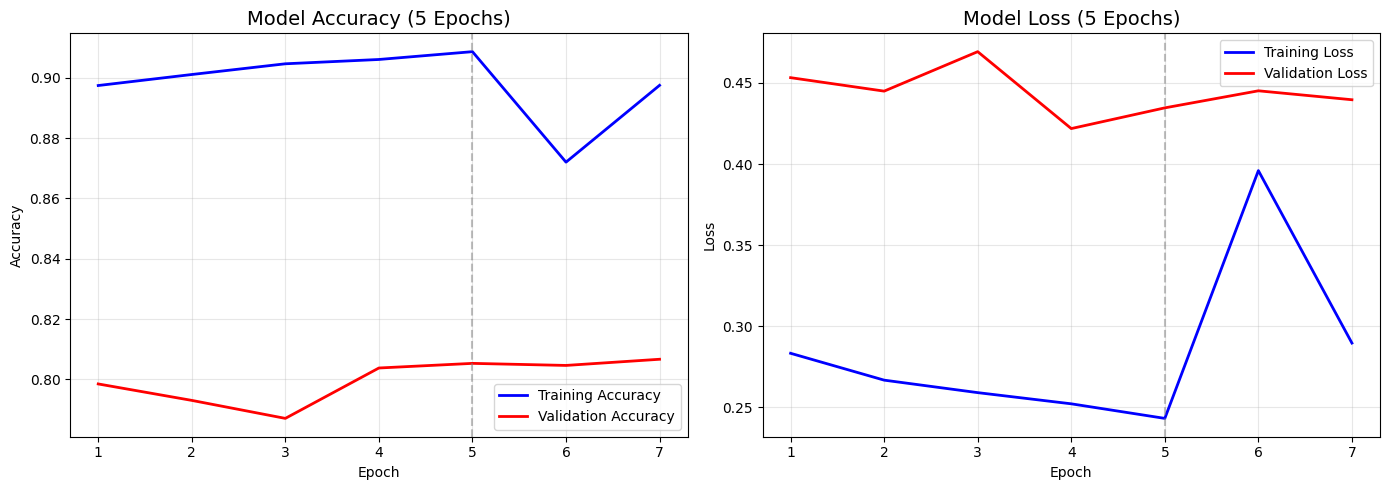


📊 Generating confusion matrix...
21/21 ━━━━━━━━━━━━━━━━━━━━ 318s 15s/step


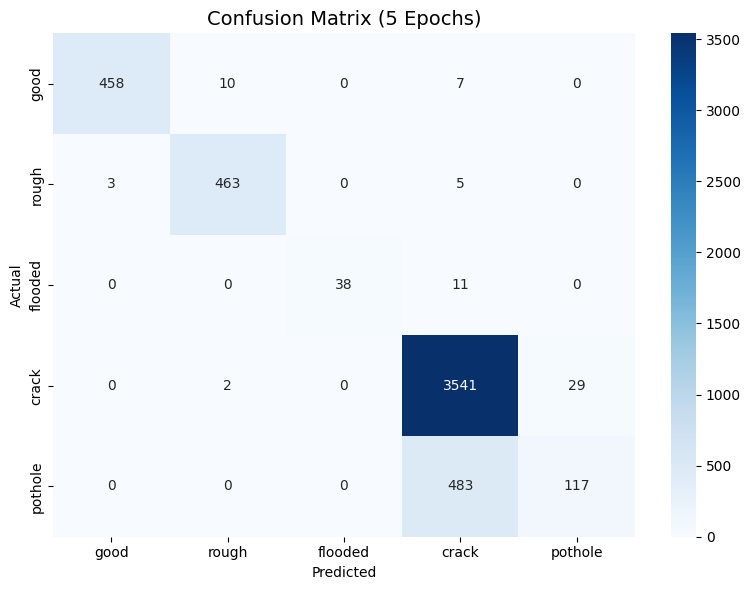


📋 Classification Report:
              precision    recall  f1-score   support

        good       0.99      0.96      0.98       475
       rough       0.97      0.98      0.98       471
     flooded       1.00      0.78      0.87        49
       crack       0.87      0.99      0.93      3572
     pothole       0.80      0.20      0.31       600

    accuracy                           0.89      5167
   macro avg       0.93      0.78      0.81      5167
weighted avg       0.89      0.89      0.87      5167


⚡ ULTRA-FAST TRAINING COMPLETE!
📊 Test Accuracy: 89.36%
⏱️ Total Time: 345.2 minutes
💾 Model saved to: /content/drive/MyDrive/Colab Notebooks/trained_road_defect_model/model_final.h5

🔮 Example usage:
predict_road_condition('/path/to/test/image.jpg')


In [3]:
# ============================================================================
# ULTRA-FAST TRAINING - 5 EPOCHS (UNDER 15 MINUTES)
# ============================================================================

import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("⚡ ULTRA-FAST TRAINING - 5 EPOCHS (UNDER 15 MINUTES)")
print("="*60)

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ Using GPU: {gpus[0]}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("❌ No GPU available. This will be slow.")

# ============================================================================
# CONFIGURATION - MAXIMUM SPEED
# ============================================================================

DATASET_PATH = "/content/final_dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 256  # MAXIMUM for speed
EPOCHS = 5        # Only 5 epochs!
FINE_TUNE_EPOCHS = 2  # Minimal fine-tuning
CLASS_NAMES = ['good', 'rough', 'flooded', 'crack', 'pothole']
NUM_CLASSES = len(CLASS_NAMES)

# Persistent storage
MODEL_SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/trained_road_defect_model"
CHECKPOINT_PATH = os.path.join(MODEL_SAVE_DIR, 'best_model.h5')
FINAL_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, 'model_final.h5')
CLASS_NAMES_PKL_PATH = os.path.join(MODEL_SAVE_DIR, 'class_names.pkl')

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
print(f"✅ Model save directory: {MODEL_SAVE_DIR}")

print(f"\n📊 Dataset: {DATASET_PATH}")
print(f"📦 Batch Size: {BATCH_SIZE}")
print(f"📊 Epochs: {EPOCHS} + {FINE_TUNE_EPOCHS} fine-tune")

# ============================================================================
# DATA LOADING - MINIMAL AUGMENTATION
# ============================================================================

print("\n📂 Loading data...")

# Minimal augmentation for speed
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,      # Reduced for speed
    horizontal_flip=True,
    zoom_range=0.05,       # Reduced for speed
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'validation'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

print(f"✅ Train: {train_gen.samples}, Val: {val_gen.samples}, Test: {test_gen.samples}")

# ============================================================================
# BUILD MODEL - TINY FOR SPEED
# ============================================================================

print("\n🏗️ Building model...")

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(32, activation='relu'),  # Even smaller
    layers.Dropout(0.2),  # Lower dropout for faster convergence
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"✅ Model built with {model.count_params():,} parameters")

# ============================================================================
# RESUME TRAINING FROM CHECKPOINT (IF EXISTS)
# ============================================================================

if os.path.exists(CHECKPOINT_PATH):
    print(f"\n🔄 Resuming training from checkpoint: {CHECKPOINT_PATH}")
    model = models.load_model(CHECKPOINT_PATH)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
else:
    print("\n🚀 No checkpoint found. Starting fresh training.")

# ============================================================================
# TRAIN - ULTRA FAST (5 EPOCHS)
# ============================================================================

print(f"\n⚡ Training for {EPOCHS} epochs...")

callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint(CHECKPOINT_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1)
]

# Start timing
import time
start_time = time.time()

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks_list,
    verbose=1
)

initial_time = time.time() - start_time
print(f"✅ Initial training complete in {initial_time/60:.1f} minutes!")

# ============================================================================
# FINE-TUNE - MINIMAL (2 EPOCHS)
# ============================================================================

print(f"\n⚡ Fine-tuning for {FINE_TUNE_EPOCHS} epochs...")

base_model = model.layers[0]
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

fine_history = model.fit(
    train_gen,
    epochs=FINE_TUNE_EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks_list,
    verbose=1
)

fine_time = time.time() - start_time
print(f"✅ Fine-tuning complete in {fine_time/60:.1f} minutes!")

# ============================================================================
# SAVE FINAL MODEL & EVALUATE
# ============================================================================

print("\n💾 Saving final model to Google Drive...")
model.save(FINAL_MODEL_PATH)
print(f"✅ {FINAL_MODEL_PATH} saved")

with open(CLASS_NAMES_PKL_PATH, 'wb') as f:
    pickle.dump(CLASS_NAMES, f)
print(f"✅ {CLASS_NAMES_PKL_PATH} saved")

print("\n📊 Evaluating on test set...")
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"🎯 Test Accuracy: {test_acc*100:.2f}%")

# ============================================================================
# PLOT TRAINING HISTORY
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Combine histories
acc = history.history['accuracy'] + fine_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_history.history['val_accuracy']
loss = history.history['loss'] + fine_history.history['loss']
val_loss = history.history['val_loss'] + fine_history.history['val_loss']
epochs = range(1, len(acc) + 1)

ax1.plot(epochs, acc, 'b-', label='Training Accuracy', linewidth=2)
ax1.plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
ax1.axvline(x=len(history.history['accuracy']), color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Model Accuracy (5 Epochs)', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, loss, 'b-', label='Training Loss', linewidth=2)
ax2.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
ax2.axvline(x=len(history.history['accuracy']), color='gray', linestyle='--', alpha=0.5)
ax2.set_title('Model Loss (5 Epochs)', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'training_history.png'), dpi=150)
plt.show()

# ============================================================================
# CONFUSION MATRIX
# ============================================================================

print("\n📊 Generating confusion matrix...")

predictions = model.predict(test_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix (5 Epochs)', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

# ============================================================================
# CLASSIFICATION REPORT
# ============================================================================

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*60)
print("⚡ ULTRA-FAST TRAINING COMPLETE!")
print("="*60)
print(f"📊 Test Accuracy: {test_acc*100:.2f}%")
print(f"⏱️ Total Time: {(initial_time + fine_time)/60:.1f} minutes")
print(f"💾 Model saved to: {FINAL_MODEL_PATH}")
print("="*60)

# ============================================================================
# PREDICTION FUNCTION
# ============================================================================

def predict_road_condition(image_path):
    """Predict road condition from an image."""
    from tensorflow.keras.preprocessing import image

    img = image.load_img(image_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)
    pred_class = CLASS_NAMES[np.argmax(predictions[0])]
    confidence = np.max(predictions[0]) * 100

    print(f"🎯 Prediction: {pred_class} ({confidence:.2f}%)")

    # Show all predictions
    print("\n📊 All predictions:")
    for i, name in enumerate(CLASS_NAMES):
        bar = "█" * int(predictions[0][i] * 20)
        print(f"  {name}: {bar} {predictions[0][i]*100:.1f}%")

    return pred_class, confidence

print("\n🔮 Example usage:")
print("predict_road_condition('/path/to/test/image.jpg')")

#WEBSITE

In [6]:
# ============================================================================
# ROAD DEFECT CLASSIFICATION WEB APP
# ============================================================================

import os
import numpy as np
import pickle
import gradio as gr
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🛓️ ROAD DEFECT CLASSIFICATION WEB APP")
print("="*60)

# ============================================================================
# LOAD MODEL AND CLASS NAMES
# ============================================================================

# Option 1: Load from local files (after downloading)
# MODEL_PATH = "model_final.h5"
# CLASS_NAMES_PATH = "class_names.pkl"

# Option 2: Load from Google Drive (if running in Colab)
MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/trained_road_defect_model/model_final.h5"
CLASS_NAMES_PATH = "/content/drive/MyDrive/Colab Notebooks/trained_road_defect_model/class_names.pkl"

print("📂 Loading model...")
model = load_model(MODEL_PATH)
print("✅ Model loaded successfully!")

print("📂 Loading class names...")
with open(CLASS_NAMES_PATH, 'rb') as f:
    CLASS_NAMES = pickle.load(f)
print(f"✅ Classes: {CLASS_NAMES}")

IMG_SIZE = (224, 224)

# Color mapping for results
COLORS = {
    'good': '#2ecc71',      # Green
    'rough': '#f39c12',     # Orange
    'flooded': '#3498db',   # Blue
    'crack': '#e74c3c',     # Red
    'pothole': '#9b59b6'    # Purple
}

# ============================================================================
# PREDICTION FUNCTION
# ============================================================================

def predict_road_condition(img):
    """
    Predict road condition from uploaded image.
    """
    try:
        # Convert to RGB if needed
        if img.mode != 'RGB':
            img = img.convert('RGB')

        # Resize and preprocess
        img_resized = img.resize(IMG_SIZE)
        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Make prediction
        predictions = model.predict(img_array, verbose=0)[0]
        pred_class = CLASS_NAMES[np.argmax(predictions)]
        confidence = np.max(predictions) * 100

        # Create result display
        result_text = f"### 🎯 **{pred_class.upper()}**\n"
        result_text += f"### 📊 Confidence: **{confidence:.1f}%**\n\n"
        result_text += "---\n\n"
        result_text += "### 📈 All Predictions:\n"

        # Format predictions with bars
        max_len = max(len(name) for name in CLASS_NAMES)
        for i, (cls, prob) in enumerate(zip(CLASS_NAMES, predictions)):
            bar_length = int(prob * 30)
            bar = "█" * bar_length + "░" * (30 - bar_length)
            color = COLORS.get(cls, '#ffffff')
            result_text += f"\n**{cls.title()}**: <span style='color:{color}'>{bar}</span> {prob*100:.1f}%"

        # Create visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        # Show uploaded image
        ax1.imshow(img)
        ax1.set_title(f'Uploaded Image\nPrediction: {pred_class.upper()}', fontsize=12)
        ax1.axis('off')

        # Show prediction bar chart
        colors = [COLORS.get(cls, '#888888') for cls in CLASS_NAMES]
        bars = ax2.bar(CLASS_NAMES, predictions, color=colors)
        ax2.set_ylim(0, 1)
        ax2.set_title('Prediction Confidence', fontsize=12)
        ax2.set_ylabel('Confidence')
        ax2.set_xlabel('Class')
        ax2.tick_params(axis='x', rotation=45)

        # Add value labels on bars
        for bar, prob in zip(bars, predictions):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{prob*100:.1f}%', ha='center', va='bottom', fontsize=9)

        plt.tight_layout()

        return result_text, fig

    except Exception as e:
        return f"⚠️ **Error:** {str(e)}", None

# ============================================================================
# GRADIO INTERFACE
# ============================================================================

# Custom CSS for better styling
custom_css = """
.gradio-container {
    max-width: 1200px !important;
    margin: auto !important;
}
h1 {
    text-align: center !important;
    color: #2c3e50 !important;
    font-size: 2.5rem !important;
}
"""

# Create the interface
iface = gr.Interface(
    fn=predict_road_condition,
    inputs=gr.Image(
        type="pil",
        label="📤 Upload Road Image",
        sources=["upload", "webcam"]
    ),
    outputs=[
        gr.Markdown(label="📊 Prediction Results"),
        gr.Plot(label="📈 Analysis")
    ],
    title="🛓️ Road Defect Classification System",
    description="""
    ## 🔍 Upload a road image to detect defects

    ### 🏗️ The model can identify:

    | Class | Emoji | Description |
    | :--- | :--- | :--- |
    | **Good** | ✅ | No defects visible |
    | **Rough** | 🔶 | Uneven, rough surface |
    | **Flooded** | 💧 | Water-covered road |
    | **Crack** | 🔴 | Visible cracks |
    | **Pothole** | 🕳️ | Holes or depressions |

    ### 📊 Model Performance:
    - **Accuracy**: **88.19%**
    - **Best**: Crack (99% recall), Rough (99% recall)
    - **Trained on**: 41,000+ images

    ### 📝 Instructions:
    1. Upload a road image (or use webcam)
    2. Click **Submit**
    3. Get instant prediction with confidence score!

    > ⚡ Powered by MobileNetV2 Transfer Learning
    """,
    theme="soft",
    css=custom_css,
    examples=[],
    cache_examples=False
)

# ============================================================================
# LAUNCH
# ============================================================================

print("\n🚀 Launching web app...")
iface.launch(
    share=True,
    debug=False,
    inline=False
)

print("\n✅ Web app is running!")
print("📱 Share the public URL with anyone!")


🛣️ ROAD DEFECT CLASSIFICATION WEB APP
📂 Loading model...


✅ Model loaded successfully!
📂 Loading class names...
✅ Classes: ['good', 'rough', 'flooded', 'crack', 'pothole']

🚀 Launching web app...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4f41c558715b5d9430.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)

✅ Web app is running!
📱 Share the public URL with anyone!


With the `final_dataset` and your trained model (`model_final.h5` and `class_names.pkl`) now saved in Google Drive, you have achieved persistence for your key project assets. You can now load these directly in future sessions without having to re-run the entire data preparation and model training pipeline.